In [1]:
import operator
from typing import List
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph,START, END, MessagesState

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, AnyMessage, ToolMessage
import os
from dotenv import load_dotenv
load_dotenv()
import warnings
warnings.filterwarnings('ignore')

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="qwen/qwen3-32b")


/Users/mohanreddypanga/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# from langchain.tools import tool


In [2]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply tow integer number
    
    Args:
        a (int): the first integer
        b (int): the second integer
    
    """
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Add two number
    
    Args:
        a (int): the first integer
        b (int): the second integer
    
    """
    return a + b
@tool
def divide(a: int, b: int) -> float:
    """Divide two number and return a float
    
    Args:
        a (int): the first integer
        b (int): the second integer
    
    """
    pass

## build in tools - Web Search

In [3]:
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

from langchain_tavily import TavilySearch

search = TavilySearch(
    max_results=3,
    topic="general"
)

In [6]:
response = search.invoke("Capital of USA?")
response


{'query': 'Capital of USA?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'Washington, D.C. - Wikipedia',
   'url': 'https://en.wikipedia.org/wiki/Washington,_D.C.',
   'content': 'Washington, D.C., formally the District of Columbia and commonly known as Washington or D.C., is the capital city and federal district of the United States. The city is on the Potomac River, across from Virginia, and shares land borders with Maryland to its north and east.',
   'score': 0.68420124,
   'raw_content': None},
  {'title': 'List Of 50 States And Their Capitals - The Fact File',
   'url': 'https://thefactfile.org/u-s-states-and-capitals/',
   'content': 'List Of 50 States And Their Capitals - The Fact File 50 US States 50 US States List Of 50 States And Their Capitals It is the second largest country in North America after Canada (largest) and followed by Mexico (third largest). Here is a list of the 50 states and their capitals. 50 States And Their Capitals

In [7]:
response['results'][2]['content']


'Washington, D.C., city and capital of the United States of America. Washington, D.C., remains a territory, not a state, and since 1974 it has been governed by a locally elected mayor and city council over which Congress retains the power of veto. Despite the city’s currents of Classicism and architectural conservatism, most of Washington’s early buildings were displaced by the structures of the Modernist movement of the 20th century, which encouraged an architectural style that was devoid of decoration. Few early 19th-century buildings remain in Downtown Washington, with the exception of three houses at 637–641 Indiana Avenue, in Northwest D.C., that were built in the 1820s. Official Site for Washington, D.C., Government Information and Services'

In [8]:
tools = [multiply, add, divide, search]
llm_with_tools = llm.bind_tools(tools)


### Testing

In [10]:
response = llm_with_tools.invoke("tell me the current political status of Hyderabad,india")
response.tool_calls


[{'name': 'tavily_search',
  'args': {'query': 'current political status of Hyderabad India',
   'search_depth': 'advanced',
   'time_range': 'week',
   'topic': 'news'},
  'id': '6cskzh29n',
  'type': 'tool_call'}]

In [11]:
response = llm_with_tools.invoke("What is 2 and 2")
response.tool_calls


[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'gefv84rf4',
  'type': 'tool_call'}]

## Graph Node With System Prompt.


In [8]:
SYSTEM_PROMPT = """
You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs. Do not tools call parallel. you are woks as react agent does.\n\n
"""

In [9]:
tools = [multiply, add, divide, search]
llm_with_tools = llm.bind_tools(tools)

def call_model(state: MessagesState):
    question = state["messages"]
    
    question_with_system_prompt = [SYSTEM_PROMPT] + question
    
    response = llm_with_tools.invoke(question_with_system_prompt)
    
    return {
        "messages": [response]
    }

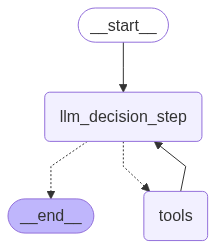

In [10]:
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(MessagesState) 

tools = [multiply, add, divide, search]
# llm_with_tools = llm.bind_tools(tools)

builder.add_node("llm_decision_step", call_model)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm_decision_step")
builder.add_conditional_edges(
    "llm_decision_step",
    ## if last messages is tools call then call the tools
    ## if last messages is not tools call return end
    tools_condition
)
builder.add_edge("tools", "llm_decision_step")

react_agent = builder.compile()

from IPython.display import display, Image

display(Image(react_agent.get_graph().draw_mermaid_png()))

### Testing

In [11]:
output = react_agent.invoke(
    {
        "messages": ["what is 2 and 6 then multiply with 10"]
    }
)

for m in output["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 and 6 then multiply with 10
================================== Ai Message ==================================
Tool Calls:
  add (hqptq6mrj)
 Call ID: hqptq6mrj
  Args:
    a: 2
    b: 6
  multiply (9k8d7g36c)
 Call ID: 9k8d7g36c
  Args:
    a: 8
    b: 10
================================= Tool Message =================================
Name: add

8
================================= Tool Message =================================
Name: multiply

80
================================== Ai Message ==================================

The result of adding 2 and 6, then multiplying by 10 is **80**. 

**Step-by-step:**
1. Add 2 + 6 = **8**
2. Multiply 8 × 10 = **80**


In [12]:
output = react_agent.invoke(
    {
        "messages": ["what is the current population of Hyderabad city and multiply 5 with the population value"]
    }
)

for m in output["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the current population of Hyderabad city and multiply 5 with the population value
================================== Ai Message ==================================
Tool Calls:
  tavily_search (xqdq1kdw2)
 Call ID: xqdq1kdw2
  Args:
    query: current population of Hyderabad city
    search_depth: advanced
    time_range: year
================================= Tool Message =================================
Name: tavily_search

{"query": "current population of Hyderabad city", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Hyderabad Population 2025 in Crores Religion Wise - Exam days", "url": "https://examdays.com/tsap/hyderabad-population-2025-in-crores-religion-wise/", "content": "Hyderabad Population 2025: Are you looking for the Hyderabad city population? If yes.!!! Then you are in the right place for the complete population in Hyderabad as per the 2024 and 2025

## add one more finance tools


In [14]:
import yfinance as yf

@tool
def get_stock_price(ticker: str) ->str:
    """
    Fetches the previous closing price of a given stock ticker form Yahoo Finance.
    
    Args:
        ticker (str): The stock ticker symbol (e.g., 'AAPL', 'TSLA', 'MSFT')
        
    Returns:
        str: A messages with the stock's previous closing price.
    """
    
    try:
        stock = yf.Ticker(ticker)
        price = stock.info.get("previousClose")
        if price is None:
            return f"Could not fetch price for ticker '{ticker}'."
        return f"the last closing price of {ticker.upper()} was ${price:.2f}."
    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"

In [15]:
get_stock_price.invoke(
    {
        "ticker": "AAPL"
    }
)

'the last closing price of AAPL was $212.44.'

## Build TOOL

In [16]:
tools = [add, multiply, divide, search, get_stock_price]

llm_with_tools = llm.bind_tools(tools)

In [17]:
response = llm_with_tools.invoke("Can you give me the latest stock price of Nvidia")
response.tool_calls


[{'name': 'get_stock_price',
  'args': {'ticker': 'NVDA'},
  'id': 'b3172mne1',
  'type': 'tool_call'}]

In [ ]:
SYSTEM_PROMPT = """
You are a helpful assistant tasked with using search the yahoo finance tool and performing arithmetic on a set of inputs. Do not tools call parallel. you are woks as react agent does.\n\n
"""

def call_model(state: MessagesState):
    question = state["messages"]
    
    question_with_system_prompt = [SYSTEM_PROMPT] + question
    
    response = llm_with_tools.invoke(question_with_system_prompt)
    
    return {
        "messages": [response]
    }

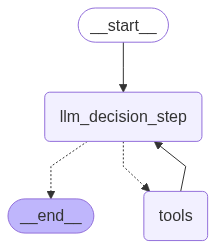

In [18]:
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(MessagesState) 

builder.add_node("llm_decision_step", call_model)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm_decision_step")
builder.add_conditional_edges(
    "llm_decision_step",
    ## if last messages is tools call then call the tools
    ## if last messages is not tools call return end
    tools_condition
)
builder.add_edge("tools", "llm_decision_step")

react_agent = builder.compile()

from IPython.display import display, Image

display(Image(react_agent.get_graph().draw_mermaid_png()))

In [22]:
output = react_agent.invoke(
    {
        "messages": ["multiply the current stock price of Apple with population of Hyderabad,India"]
    }
)

for m in output["messages"]:
    m.pretty_print()

================================ Human Message =================================

multiply the current stock price of Apple with population of Hyderabad,India
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (j3dakzvwe)
 Call ID: j3dakzvwe
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: get_stock_price

the last closing price of AAPL was $212.44.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (nhw13742d)
 Call ID: nhw13742d
  Args:
    query: current population of Hyderabad, India
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "current population of Hyderabad, India", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Hyderabad, India Metro Area Population (1950-2025) - Macrotrend